# RouteScout — Real-board router intervention

Phase 8B tests whether **MST-hard-first** changes routing outcomes relative to natural net order on a
locked set of PCBench-derived real boards.

The default path below is an **analysis-only replay of the frozen 72 policy runs**. It is fast,
works on a normal Python environment, and cannot accidentally rerun or retune the experiment.

A full Linux/KiCad rerun is documented separately at the end.


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

from routescout.evaluation import analyze_phase8b, paired_table
from routescout.integrity import validate_phase8b_run_table

ROOT = Path.cwd()
if not (ROOT / "results").exists() and (ROOT.parent / "results").exists():
    ROOT = ROOT.parent

runs = pd.read_csv(ROOT / "results" / "phase8b_policy_runs_frozen.csv")
runs["api_error"] = runs["api_error"].fillna("")

manifest = json.loads(
    (ROOT / "configs" / "phase8b_exact_manifest_v4.json").read_text()
)
frozen = json.loads(
    (ROOT / "results" / "phase8b_frozen_result.json").read_text()
)

validate_phase8b_run_table(runs, manifest)
print("rows:", len(runs))
print("boards:", runs["d3_id"].nunique())
print("api errors:", runs["api_error"].ne("").sum())
print("exact issued order:", runs["issued_order_exact"].astype(bool).sum())


rows: 72
boards: 24
api errors: 0
exact issued order: 72


## Recompute the preregistered paired analysis

The analysis uses the same board-level pairing and 10,000-sample bootstrap rule as the frozen
experiment. Replaying the analysis does not reopen the scientific decision.


In [2]:
result, policy_summary = analyze_phase8b(runs)
policy_summary.round(5)


,policy,boards,target_routability,target_success,target_clean_success,full_drc_errors,action_failure_count,wirelength_mm,via_count,elapsed_seconds
0,mst_easy_first,24,0.20072,0.04167,0.04167,9.66667,11.00000,602.88560,14.54167,2.72815
1,mst_hard_first,24,0.20866,0.08333,0.08333,9.62500,10.95833,607.06826,14.54167,2.86620
2,natural,24,0.19576,0.04167,0.04167,9.70833,11.04167,604.53591,14.54167,2.98827


In [3]:
assert result["decision"] == frozen["decision"]
assert result["valid_boards"] == frozen["valid_boards"]
assert result["common_valid_boards"] == frozen["common_valid_boards"]

for metric in (
    "target_routability",
    "whole_board_drc_errors",
    "target_clean_success",
    "action_failure_count",
    "wirelength_mm_common_valid",
    "via_count_common_valid",
):
    assert (
        result["hard_minus_natural"][metric]
        == frozen["hard_minus_natural"][metric]
    )

print("Frozen analysis replay: PASS")
print("Decision:", result["decision"])


Frozen analysis replay: PASS
Decision: NO_CLEAR_ROUTABILITY_BENEFIT


## Evidence figures

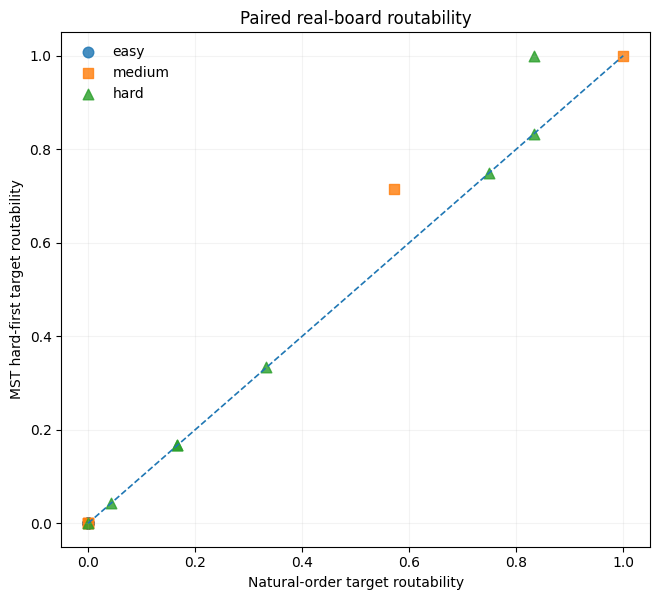

In [4]:
paired = paired_table(runs, "target_routability").reset_index()

fig, ax = plt.subplots(figsize=(6.7, 6.1))
markers = {"easy": "o", "medium": "s", "hard": "^"}
for difficulty, marker in markers.items():
    data = paired[paired["difficulty"] == difficulty]
    ax.scatter(
        data["natural"],
        data["mst_hard_first"],
        s=58,
        marker=marker,
        alpha=0.82,
        label=difficulty,
    )

lower = float(min(paired["natural"].min(), paired["mst_hard_first"].min(), 0))
ax.plot([lower, 1], [lower, 1], "--", linewidth=1.2)
ax.set_xlabel("Natural-order target routability")
ax.set_ylabel("MST hard-first target routability")
ax.set_title("Paired real-board routability")
ax.legend(frameon=False)
ax.grid(alpha=0.15)
plt.tight_layout()
plt.show()


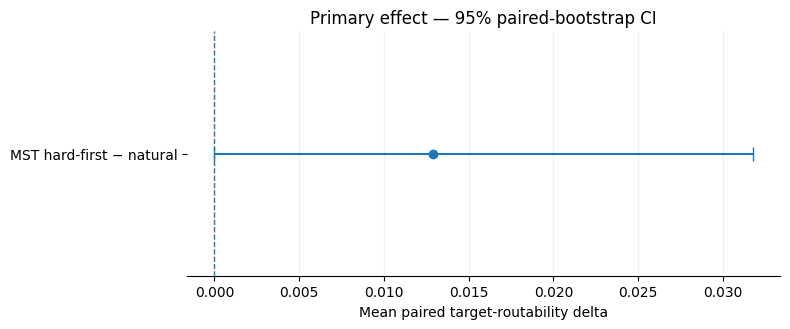

In [5]:
ci = result["hard_minus_natural"]["target_routability"]
mean = ci["mean"]
low, high = ci["ci95"]

fig, ax = plt.subplots(figsize=(8.0, 3.4))
ax.axvline(0, linestyle="--", linewidth=1)
ax.errorbar(
    [mean],
    [0],
    xerr=[[mean - low], [high - mean]],
    fmt="o",
    capsize=5,
)
ax.set_yticks([0])
ax.set_yticklabels(["MST hard-first − natural"])
ax.set_xlabel("Mean paired target-routability delta")
ax.set_title("Primary effect — 95% paired-bootstrap CI")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.18)
plt.tight_layout()
plt.show()


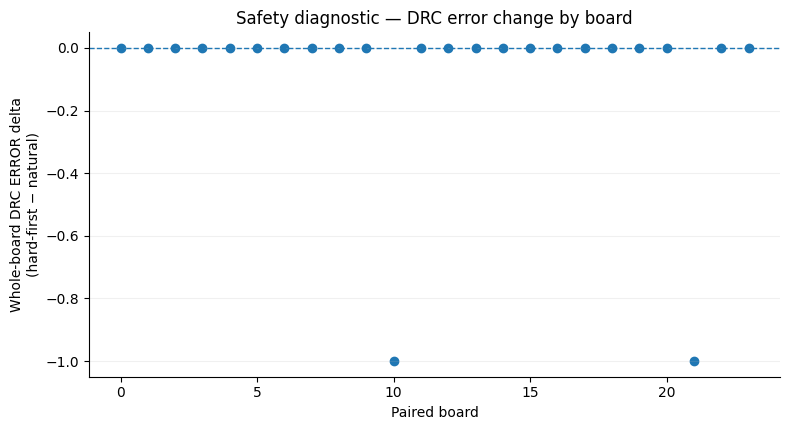

In [6]:
drc = paired_table(runs, "full_drc_errors").reset_index()
drc["delta"] = drc["mst_hard_first"] - drc["natural"]

fig, ax = plt.subplots(figsize=(8.0, 4.4))
ax.scatter(range(len(drc)), drc["delta"])
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xlabel("Paired board")
ax.set_ylabel("Whole-board DRC ERROR delta\n(hard-first − natural)")
ax.set_title("Safety diagnostic — DRC error change by board")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.18)
plt.tight_layout()
plt.show()


## Frozen interpretation

Hard-first has a small positive routability point estimate, but the preregistered 95% confidence
interval touches zero.

**Frozen decision: `NO_CLEAR_ROUTABILITY_BENEFIT`.**

That result is preserved even though the point estimate is directionally favorable.


## Optional full router rerun — Linux / Colab only

The full experiment is intentionally **not** triggered by `Run All`.

To reproduce the engineering stack:

```bash
python scripts/bootstrap_phase8b.py --root .work/phase8b
python scripts/materialize_phase8b_locked_inputs.py \
  --state .work/phase8b/artifacts/clean_bootstrap_state.json \
  --manifest configs/phase8b_exact_manifest_v4.json \
  --workers 2 \
  --output .work/phase8b/artifacts/runtime_manifest.json
```

Then invoke the locked runner:

`src/routescout/phase8b_runner.py`

The frozen runner SHA-256 is:

`ad97beed8ca97ee98f50634724269987c260c2f764642c75c71b4722a15344a0`

A full rerun is for reproducibility work only. It is not allowed to change the frozen decision.
